# Обзор

Данные были разделены на две группы:

* обучающий набор (game_of_thrones_train.csv)
* тестовый набор (game_of_thrones_test.csv)
В данном задании будем работать с датасетом о персонажах из вселенной Игры Престолов. На тестовых данных будем предсказывать, кто из персонажей умрет, а кто останется вживых.

### Импортируем нужные библиотеки

In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\79825\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


#### Считываем данные с файла game_of_thrones_train.csv

In [4]:
df = pd.read_csv('game_of_thrones_train.csv')

Для начала изучим структуру данных

Описание данных:
* name: Имя персонажа
* Title: Социальный статус или знатность
* House: Дом, к которому принадлежит персонаж
* Culture: Социальная группа, к которой принадлежит персонаж
* book1/2/3/4/5: Появление персонажа в книге
* Is noble: Знатность персонажа, основанное на титуле
* Age: Отсчет времени: 305 AC
* male: Мужчина или женщина
* dateOfBirth: дата рождения
* Spouse: Имя супруги\а персонажа
* Father: Имя отца персонажа
* Mother: Имя матери персонажа
* Heir: Имя наследника персонажа
* Is married: Represents whether the character is married
* Is spouse alive: Represents whether character's spouse is alive
* Is mother alive: Жива ли мать персонажа
* Is heir alive: Жив ли наследник персонажа
* Is father alive: Указывает, жив ли отец персонажа
* Number dead relations: Количество умерших персонажей, с которыми персонаж связан
* Popularity score: Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* isAlive: жив ли персонаж в книге

In [5]:
df

,S.No,name,title,male,culture,dateOfBirth,mother,father,heir,house,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
0,1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
1,2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
2,3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
3,4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
4,5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,1553,Marwyn,Archmaester,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.160535,1
1553,1554,Masha Heddle,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.040134,0
1554,1555,Matthos Seaworth,NaN,1,NaN,NaN,NaN,NaN,NaN,House Seaworth,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.076923,0
1555,1556,Meera Reed,NaN,0,Crannogmen,283.0,NaN,NaN,NaN,House Reed,...,NaN,NaN,NaN,NaN,0,0,22.0,0,0.270903,1


#### Сделаем значения столбца S.No наименованиями строк

In [6]:
data = pd.read_csv('game_of_thrones_train.csv', index_col='S.No')

In [7]:
data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Viserys II Targaryen,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


In [8]:
data.describe(include = ['number']).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


In [9]:
data.isna()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,False,True,False,True,True,False,False,False,True,True,...,False,False,False,True,False,False,True,False,False,False
2,False,False,False,False,False,True,True,True,False,False,...,True,True,True,False,False,False,False,False,False,False
3,False,False,False,True,True,True,True,True,False,True,...,True,True,True,True,False,False,True,False,False,False
4,False,False,False,True,False,True,True,True,False,False,...,True,True,True,False,False,False,False,False,False,False
5,False,False,False,False,False,True,True,True,False,False,...,True,True,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,False,False,False,True,True,True,True,True,True,True,...,True,True,True,True,False,False,True,False,False,False
1554,False,True,False,True,True,True,True,True,True,True,...,True,True,True,True,False,False,True,False,False,False
1555,False,True,False,True,True,True,True,True,False,True,...,True,True,True,True,False,False,True,False,False,False


Построим гистограмму распределения признака popularity с количеством интервалов (bins), равным 50

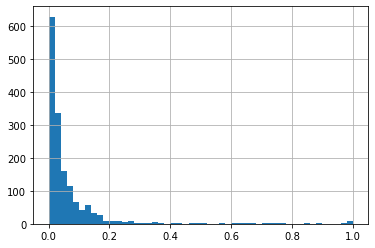

In [10]:
hist = data['popularity'].hist(bins=50)

Преобразуем данный признак при помощи формулы np.log10(data["popularity"]*М+1

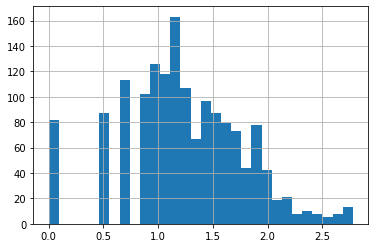

In [23]:
hist = np.log10(data["popularity"]*600+1).hist(bins=30) #симметризуем распределение

Обработаем признак numDeadRelations. Лишь для малого числа персонажей numDeadRelations > 0. Создайдим признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.

In [24]:
data['boolDeadRelations'] = data['numDeadRelations'] > 0 #создание признака

У признака age много пропущенных значений. 
* Там где возраст указан, age_value принимает значение age, а age_no_data - значение 0.
* Там где возраст не указан, age_value принимает значение 0, а age_no_data - значение 1.

In [26]:
data['age_value'] = [0 if np.isnan(x) else 1 for x in data['age']]
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]

In [27]:
data.value_counts(dropna=False)

name              title     male  culture   dateOfBirth  mother  father  heir  house             spouse        book1  book2  book3  book4  book5  isAliveMother  isAliveFather  isAliveHeir  isAliveSpouse  isMarried  isNoble  age   numDeadRelations  popularity  isAlive  boolDeadRelations  age_value  age_no_data
Abelar Hightower  Ser       1     NaN       NaN          NaN     NaN     NaN   House Hightower   NaN           0      0      0      0      0      NaN            NaN            NaN          NaN            0          1        NaN   0                 0.000000    1        False              0          1              1
Narbo             NaN       0     Braavosi  NaN          NaN     NaN     NaN   NaN               NaN           0      0      0      1      0      NaN            NaN            NaN          NaN            0          0        NaN   0                 0.010033    1        False              0          1              1
Olene Tyrell      NaN       0     NaN       NaN          

Признак culture содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов. Видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

In [29]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

Инвертируем словарь cultures_grouped

In [30]:
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
  for v in cultures_grouped[k]:
      cultures_grouped_inverted.update({v:k})

cultures_grouped_inverted

{'valyrian': 'Old Nations',
 'first men': 'Old Nations',
 'andal': 'Old Nations',
 'andals': 'Old Nations',
 'rhoynar': 'Old Nations',
 'northmen': 'the North',
 'northern mountain clans': 'the North',
 'crannogmen': 'the North',
 'ironborn': 'the Iron Islands',
 'ironmen': 'the Iron Islands',
 'valemen': 'the Mountain and the Vale',
 'vale': 'the Mountain and the Vale',
 'vale mountain clans': 'the Mountain and the Vale',
 'sistermen': 'the Mountain and the Vale',
 'riverlands': 'the Isles and Rivers',
 'rivermen': 'the Isles and Rivers',
 'westerman': 'the Rock',
 'westermen': 'the Rock',
 'westerlands': 'the Rock',
 'stormlander': 'the Stormlands',
 'stormlands': 'the Stormlands',
 'reach': 'the Reach',
 'reachmen': 'the Reach',
 'the reach': 'the Reach',
 'dornish': 'Dorne',
 'dornishmen': 'Dorne',
 'dorne': 'Dorne',
 'astapor': 'Essos Nations',
 'astapori': 'Essos Nations',
 'braavosi': 'Essos Nations',
 'braavos': 'Essos Nations',
 'tyroshi': 'Essos Nations',
 'lysene': 'Essos Na

In [31]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)

In [32]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted).fillna('culture_no_data')
data['culture_grouped'] 

S.No
1            culture_no_data
2       the Isles and Rivers
3            culture_no_data
4            culture_no_data
5                      Dorne
                ...         
1553         culture_no_data
1554         culture_no_data
1555         culture_no_data
1556               the North
1557         culture_no_data
Name: culture_grouped, Length: 1557, dtype: object

Категориальные признаки в линейных моделях. Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования.
В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком culture.

In [34]:
# Количество уникальнх значений в каждом столбце
data.nunique()

name                 1557
title                 195
male                    2
culture                51
dateOfBirth           105
mother                 16
father                 19
heir                   20
house                 315
spouse                186
book1                   2
book2                   2
book3                   2
book4                   2
book5                   2
isAliveMother           2
isAliveFather           2
isAliveHeir             2
isAliveSpouse           2
isMarried               2
isNoble                 2
age                    72
numDeadRelations       14
popularity            117
isAlive                 2
boolDeadRelations       2
age_value               2
age_no_data             2
culture_grouped        12
dtype: int64

In [35]:
data.describe(include = ['number']).T[['count', 'min', 'max']].assign(N_unique_values = data.nunique())

,count,min,max,N_unique_values
male,1557.0,0.0,1.0,2
dateOfBirth,279.0,-25.0,299.0,105
book1,1557.0,0.0,1.0,2
book2,1557.0,0.0,1.0,2
book3,1557.0,0.0,1.0,2
book4,1557.0,0.0,1.0,2
book5,1557.0,0.0,1.0,2
isAliveMother,18.0,0.0,1.0,2
isAliveFather,22.0,0.0,1.0,2
isAliveHeir,21.0,0.0,1.0,2


In [36]:
df.columns

Index(['S.No', 'name', 'title', 'male', 'culture', 'dateOfBirth', 'mother',
       'father', 'heir', 'house', 'spouse', 'book1', 'book2', 'book3', 'book4',
       'book5', 'isAliveMother', 'isAliveFather', 'isAliveHeir',
       'isAliveSpouse', 'isMarried', 'isNoble', 'age', 'numDeadRelations',
       'popularity', 'isAlive'],
      dtype='object')

In [37]:
categorical_columns = [
    'title',           # Социальный статус (много уникальных значений)
    'house',           # Дом персонажа
    'culture',         # Социальная группа
    'isNoble',        # Знатность (бинарный)
    'male',            # Пол (бинарный)
]

In [39]:
categorical_features = df[categorical_columns]
categorical_features.columns

Index(['title', 'house', 'culture', 'isNoble', 'male'], dtype='object')

In [40]:
unprocessed_cat_features = categorical_features.select_dtypes(include=[object]).columns.tolist()

In [41]:
df[unprocessed_cat_features]

,title,house,culture
0,NaN,NaN,NaN
1,Lord of the Crossing,House Frey,Rivermen
2,Ser,House Swyft,NaN
3,Queen,House Arryn,NaN
4,Greenstone,House Santagar,Dornish
...,...,...,...
1552,Archmaester,NaN,NaN
1553,NaN,NaN,NaN
1554,NaN,House Seaworth,NaN
1555,NaN,House Reed,Crannogmen


In [23]:
df.title.unique()

array([nan, 'Lord of the Crossing', 'Ser', 'Queen', 'Greenstone',
       'Hand of the King', 'Archmaester', 'Maester', 'Khal', 'red hand',
       'Castellan', 'Seven Kingdoms', 'PrincessQueen',
       'Lord of the Iron Islands', 'Lord', 'Brother', 'Lord of Coldmoat',
       'Prince of Dragonstone', 'Lady', 'PrincessSepta', 'Princess',
       'Septa', 'Grand Maester', 'Septon', 'King', 'Seneschal',
       'Bloodrider', 'Stokeworth', 'Prince', 'LadyQueenDowager Queen',
       'Lord of the Tides', 'Lord of Dragonstone', 'Goodman', 'Wisdom',
       'King in the North', 'Winterfell', 'Steward', 'Eyrie',
       'Casterly Rock', 'Cupbearer', 'Hornwood',
       'Lord Steward of the Iron Islands', 'Blue Grace', 'Red Priest',
       'Khalakka', 'Good Master', 'QueenBlack Bride', 'Last Hearth',
       'Lord Paramount of the Mander', 'Seagard', 'Goodwife', 'Uplands',
       'BrotherProctor', 'Coldmoat', 'Ashford', 'Wind Witch', 'LadyQueen',
       'Broad Arch', 'Brightwater', 'Lady Marya', 'Blackc

Будем обрабатывать категориальные признаки и переводить их в числа при помощи кодировщика One-Hot-Encoder

In [24]:
one_hot = pd.get_dummies(df['title'])

df_one_hot = pd.concat([df, one_hot], axis=1)

df_one_hot = df_one_hot.drop('title', axis=1)
df_one_hot

,S.No,name,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,Whitewalls,Widow's Watch,Wind Witch,Winterfell,Wisdom,Wraith,Wyndhall,Yronwood,master of ships,red hand
0,1,Viserys II Targaryen,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,2,Walder Frey,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,0,0,0,0,0,0,0,0,0,0
2,3,Addison Hill,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,0,0,0,0,0,0,0,0,0,0
3,4,Aemma Arryn,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,0,0,0,0,0,0,0,0,0,0
4,5,Sylva Santagar,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,1553,Marwyn,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1553,1554,Masha Heddle,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1554,1555,Matthos Seaworth,1,NaN,NaN,NaN,NaN,NaN,House Seaworth,NaN,...,0,0,0,0,0,0,0,0,0,0
1555,1556,Meera Reed,0,Crannogmen,283.0,NaN,NaN,NaN,House Reed,NaN,...,0,0,0,0,0,0,0,0,0,0


In [43]:
encoder = OneHotEncoder()
one_hot_encoded = encoder.fit_transform(df[unprocessed_cat_features])
one_hot_df = pd.DataFrame(one_hot_encoded.toarray(),  
                         columns=encoder.get_feature_names_out(unprocessed_cat_features), 
                         index=df.index)
one_hot_df#новая табличка

,title_Acorn Hall,title_Archmaester,title_Ashford,title_Banefort,title_Big BucketThe Wull,title_Bitterbridge,title_Blackcrown,title_Blackmont,title_Bloodrider,title_Blue Grace,...,culture_Westerlands,culture_Westerman,culture_Westermen,culture_Westeros,culture_Wildling,culture_free folk,culture_ironborn,culture_northmen,culture_westermen,culture_nan
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1553,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1554,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1555,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
df_encoded = pd.concat([df, one_hot_df], axis=1)

#удалить первоначальные столбцы
df_encoded = df_encoded.drop(unprocessed_cat_features, axis=1)

df_encoded

,S.No,name,male,dateOfBirth,mother,father,heir,spouse,book1,book2,...,culture_Westerlands,culture_Westerman,culture_Westermen,culture_Westeros,culture_Wildling,culture_free folk,culture_ironborn,culture_northmen,culture_westermen,culture_nan
0,1,Viserys II Targaryen,1,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,Walder Frey,1,208.0,NaN,NaN,NaN,Perra Royce,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Addison Hill,1,NaN,NaN,NaN,NaN,NaN,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,Aemma Arryn,0,82.0,NaN,NaN,NaN,Viserys I Targaryen,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,Sylva Santagar,0,276.0,NaN,NaN,NaN,Eldon Estermont,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,1553,Marwyn,1,NaN,NaN,NaN,NaN,NaN,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1553,1554,Masha Heddle,0,NaN,NaN,NaN,NaN,NaN,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1554,1555,Matthos Seaworth,1,NaN,NaN,NaN,NaN,NaN,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1555,1556,Meera Reed,0,283.0,NaN,NaN,NaN,NaN,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
Label encoding - в этом случае каждому уникальному значению столбца присваивается уникальное целочисленное значение.

In [45]:
from sklearn.preprocessing import LabelEncoder

label_encoding = LabelEncoder()
for column in unprocessed_cat_features:
  df[column] = label_encoding.fit_transform(df[column])

In [28]:
df.head()

,S.No,name,title,male,culture,dateOfBirth,mother,father,heir,house,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
0,1,Viserys II Targaryen,195,1,51,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,315,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
1,2,Walder Frey,115,1,31,208.0,NaN,NaN,NaN,106,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
2,3,Addison Hill,163,1,51,NaN,NaN,NaN,NaN,244,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
3,4,Aemma Arryn,145,0,51,82.0,NaN,NaN,NaN,21,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
4,5,Sylva Santagar,53,0,7,276.0,NaN,NaN,NaN,219,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


In [29]:
df.columns

Index(['S.No', 'name', 'title', 'male', 'culture', 'dateOfBirth', 'mother',
       'father', 'heir', 'house', 'spouse', 'book1', 'book2', 'book3', 'book4',
       'book5', 'isAliveMother', 'isAliveFather', 'isAliveHeir',
       'isAliveSpouse', 'isMarried', 'isNoble', 'age', 'numDeadRelations',
       'popularity', 'isAlive'],
      dtype='object')

In [46]:
#df['age'] = df.age.where((df.age > 0) & (df.age <= 120))
df['age'] = df['age'].where(df['age'].between(0, 120), np.nan)
df['age'] = df['age'].fillna(df['age'].median())

In [47]:
print(f"Min age: {df['age'].min()}")
print(f"Max age: {df['age'].max()}")
print(f"Mean age: {df['age'].mean()}")

Min age: 0.0
Max age: 100.0
Mean age: 26.023121387283236


In [48]:
numerical_columns = ['age', 'popularity']

In [49]:
num_features = df[numerical_columns]

print("Количество количественных признаков: ", len(num_features.columns))

Количество количественных признаков:  2


In [50]:
df.age.unique()

array([ 24.,  97.,  23.,  29.,  26.,  16.,  25.,  59.,  19.,  27.,  22.,
       100.,  14.,  42.,  35.,   3.,  55.,  15.,  21.,  53.,   6.,  37.,
        11.,  17.,  10.,  20.,  45.,   9.,  13.,  52.,  50.,   2.,  56.,
         0.,  39.,  12.,  85.,  54.,  28.,  31.,  61.,  18.,  70.,  94.,
        65.,  64.,  79.,  40.,  49.,  76.,  41.,   7.,   8.,  46.,  30.,
        51.,  75.,  82.,  43.,  81.,  60.,  47.,  69.,  36.,  68.,  48.,
        38.,  33.,  86.,  80.,  58.,  77.])

In [51]:
num_features

,age,popularity
0,24.0,0.605351
1,97.0,0.896321
2,24.0,0.267559
3,23.0,0.183946
4,29.0,0.043478
...,...,...
1552,24.0,0.160535
1553,24.0,0.040134
1554,24.0,0.076923
1555,22.0,0.270903


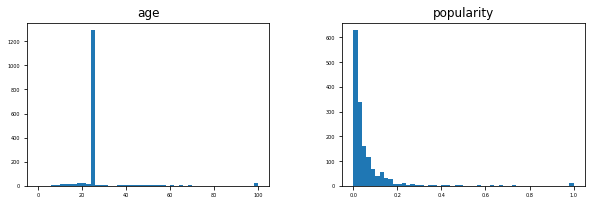

In [52]:
num_features.hist(figsize=(10, 3), bins=50,xlabelsize=5, ylabelsize=5, grid=False);

In [53]:
#sns.set()
#sns.pairplot(df, height = 2 ,kind ='scatter',diag_kind='kde') # взаимные графики на куче признаков
#plt.show()

Построим матрицу корелляций наших признаков

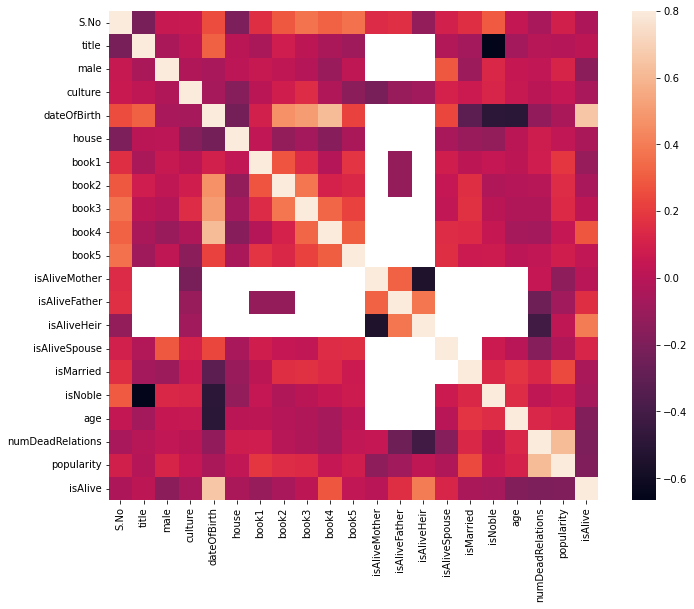

In [54]:
corrmat = df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

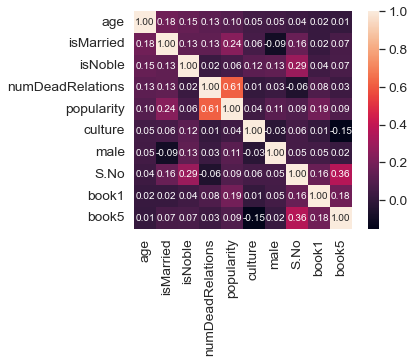

In [55]:
# correlation matrix
k = 10 # number of variables for heatmap
cols = corrmat.nlargest(k, 'age')['age'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

Проведем анализ влияния признаков на целелвую переменную isAlive

In [56]:
df['isAlive'].value_counts()

1    1212
0     345
Name: isAlive, dtype: int64

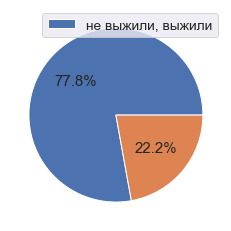

In [57]:
# готовим данные для графика
data = df['isAlive'].value_counts()

# строим круговую диаграмму
plt.pie(data, autopct='%1.1f%%')

plt.legend(['не выжили, выжили'])

plt.show()

Посмотрим, влиял ли возраст и пол на степень выживаемости

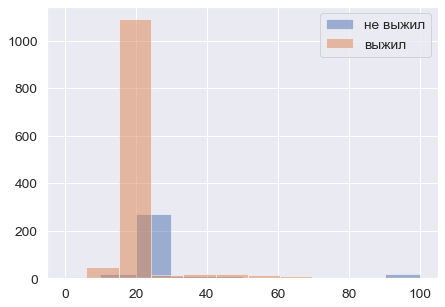

In [102]:
plt.figure(figsize=(7, 5))

plt.hist(df['age'][df['isAlive'] == 0], alpha=0.5, label='не выжил')
plt.hist(df['age'][df['isAlive'] == 1], alpha=0.5, label='выжил')

plt.legend()

plt.show()

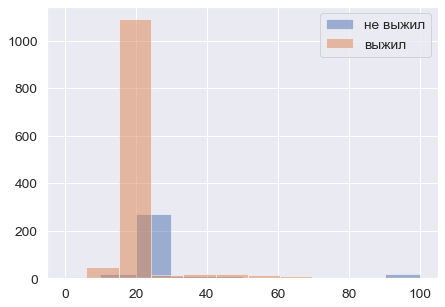

In [103]:
plt.figure(figsize=(7, 5))

plt.hist(df['age'][df['isAlive'] == 0], alpha=0.5, label='не выжил')
plt.hist(df['age'][df['isAlive'] == 1], alpha=0.5, label='выжил')

plt.legend()

plt.show()

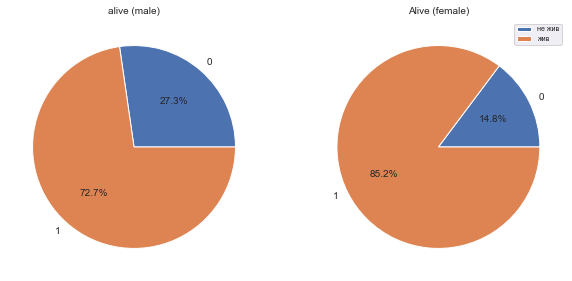

In [59]:
data_1 = df[df['male']== 1]['isAlive'].value_counts().sort_values()
data_2 = df[df['male']== 0]['isAlive'].value_counts().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8))

ax1.pie(data_1.values, labels=data_1.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.pie(data_2.values, labels=data_2.index, autopct='%1.1f%%', textprops={'fontsize': 10})

ax1.set_title('alive (male)', fontsize=10)
ax2.set_title('Alive (female)', fontsize=10)

plt.legend(['не жив', 'жив'], fontsize=7)

plt.show()

In [60]:
data1 = df['title'][df['isAlive'] == 0]
data2 = df['title'][df['isAlive'] == 1]
data1_name = data1.name
data1.head()

0    195
3    145
6     56
7    195
8    163
Name: title, dtype: int32

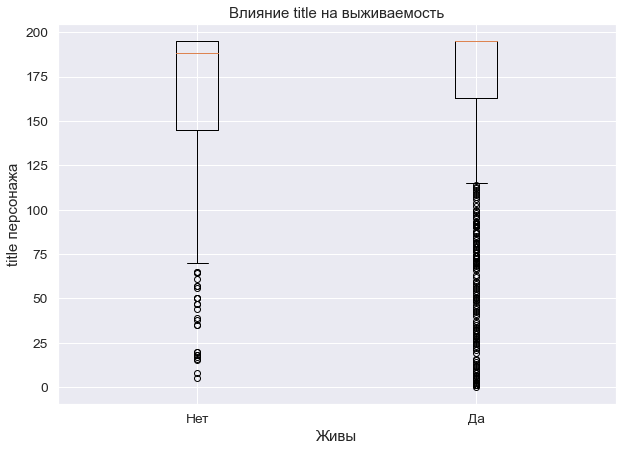

In [61]:
plt.figure(figsize=(10, 7))

plt.boxplot([data1, data2])

plt.title(f'Влияние {data1_name} на выживаемость')
plt.xlabel('Живы')
plt.ylabel(f'{data1_name} персонажа')
plt.xticks([1, 2], ['Нет', 'Да'])

plt.show()

In [62]:
first_quartile = np.quantile(df['title'].values, q=0.25)
third_quartile = np.quantile(df['title'].values, q=0.75)
print(f'1ый квартиль = {first_quartile}')
print(f'3ий квартиль = {third_quartile}')

1ый квартиль = 163.0
3ий квартиль = 195.0


In [63]:
X = df[['age', 'popularity', 'numDeadRelations', 'male', 'isNoble','culture','house']]
y = df['isAlive']

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Разделим выборку на обучающую и тестовую в соотношении 80/20, создадим модель предсказания класса при помощи логистической регрессии

In [126]:
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, shuffle=True, test_size=0.2, random_state=44)

In [127]:
model = LogisticRegression(random_state=42, max_iter=1000)

# обучение модели на тренировочных данных
model.fit(X_train, y_train)

# предсказание на валидационных данных
y_pred = model.predict(X_test)

In [128]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score, mean_absolute_error

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

MSE_train = mean_squared_error(y_train, pred_train)
RMSE_train = np.sqrt(MSE_train)
R2_train = r2_score(y_train, pred_train)
MAE_train = mean_absolute_error(y_train, pred_train)

MSE_test = mean_squared_error(y_test, pred_test)
RMSE_test = np.sqrt(MSE_test)
R2_test = r2_score(y_test, pred_test)
MAE_test = mean_absolute_error(y_test, pred_test)

print(f'MSE на обучении {MSE_train:.2f}')
print(f'MSE на тесте {MSE_test:.2f}', end='\n\n')

print(f'RMSE на обучении {RMSE_train:.2f}')
print(f'RMSE на тесте {RMSE_test:.2f}', end='\n\n')

print(f'R2 на обучении {R2_train:.2f}')
print(f'R2 на тесте {R2_test:.2f}', end='\n\n')

print(f'MAE на обучении {MAE_train:.2f}')
print(f'MAE на тесте {MAE_test:.2f}', end='\n\n')

MSE на обучении 0.21
MSE на тесте 0.18

RMSE на обучении 0.46
RMSE на тесте 0.43

R2 на обучении -0.22
R2 на тесте -0.06

MAE на обучении 0.21
MAE на тесте 0.18



In [109]:
from sklearn.metrics import accuracy_score

In [110]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.4f" % accuracy)

Accuracy: 0.8173


In [129]:
data = pd.read_csv('game_of_thrones_test.csv')
data = pd.read_csv('game_of_thrones_test.csv', index_col='S.No')

In [130]:
data['age_value'] = [0 if np.isnan(x) else 1 for x in data['age']]
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]

In [131]:
data['boolDeadRelations'] = data['numDeadRelations'] > 0 

In [132]:
data.value_counts(dropna=False)

name              title            male  culture    dateOfBirth  mother  father  heir  house             spouse             book1  book2  book3  book4  book5  isAliveMother  isAliveFather  isAliveHeir  isAliveSpouse  isMarried  isNoble  age   numDeadRelations  popularity  age_value  age_no_data  boolDeadRelations
Addam Velaryon    Ser              1     Valyrian   114.0        NaN     NaN     NaN   House Velaryon    NaN                0      0      0      0      0      NaN            NaN            NaN          NaN            0          1        16.0  0                 0.107023    1          0            False                1
Petyr Frey        NaN              1     NaN        281.0        NaN     NaN     NaN   House Frey        Mylenda Caron      0      1      1      1      0      NaN            NaN            NaN          1.0            1          0        19.0  0                 0.177258    1          0            False                1
Ravella Swann     Acorn Hall       0     NaN 

In [133]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

In [134]:
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
  for v in cultures_grouped[k]:
      cultures_grouped_inverted.update({v:k})


In [135]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted).fillna('culture_no_data')


In [136]:
data.drop(columns=['name', 'dateOfBirth', 'spouse', 'father','mother','heir'], inplace=True)

In [137]:
categorical_test_columns = [
    'title',           # Социальный статус (много уникальных значений)
    'house',           # Дом персонажа
    'culture',         # Социальная группа
    'isNoble',        # Знатность (бинарный)
    'male',            # Пол (бинарный)
]

In [138]:
categorical_test_features = data[categorical_test_columns]
categorical_test_features.columns

Index(['title', 'house', 'culture', 'isNoble', 'male'], dtype='object')

In [139]:
unprocessed_cat_test_features = categorical_test_features.select_dtypes(include=[object]).columns.tolist()

In [140]:
data[unprocessed_cat_test_features]

,title,house,culture
S.No,,,
1558,NaN,House Blackwood,NaN
1559,NaN,R'hllor,Asshai
1560,NaN,Brotherhood without banners,NaN
1561,Ser,House Trant,NaN
1562,NaN,House Frey,Riverlands
...,...,...,...
1942,NaN,House Stark,Westeros
1943,NaN,House Bolton,NaN
1944,NaN,NaN,NaN


In [141]:
from sklearn.preprocessing import OneHotEncoder
encoder_test = OneHotEncoder()
one_hot_encoded_test = encoder_test.fit_transform(data[unprocessed_cat_test_features])
one_hot_df_test = pd.DataFrame(one_hot_encoded_test.toarray(),  
                         columns=encoder_test.get_feature_names_out(unprocessed_cat_test_features), 
                         index=data.index)
one_hot_df_test

,title_Acorn Hall,title_Andals,title_Arbor,title_Barrowton,title_Bear Island,title_Black Wind,title_Blacktyde,title_Bloodrider,title_Brightwater,title_Captain-General,...,culture_Vale mountain clans,culture_Valemen,culture_Valyrian,culture_Westerlands,culture_Westerman,culture_Westermen,culture_Westeros,culture_Wildling,culture_Wildlings,culture_nan
S.No,,,,,,,,,,,,,,,,,,,,,
1558,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1559,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1560,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1561,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1562,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1943,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1944,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [143]:
one_hot_test = pd.get_dummies(data['house'])

df_one_hot_test = pd.concat([data, one_hot_test], axis=1)

df_one_hot_test = df_one_hot_test.drop('house', axis=1)
df_one_hot_test

,title,male,culture,book1,book2,book3,book4,book5,isAliveMother,isAliveFather,...,Night's Watch,R'hllor,Stone Crows,Stormcrows,Thenn,Thirteen,Three-eyed crow,Undying Ones,Unsullied,brotherhood without banners
S.No,,,,,,,,,,,,,,,,,,,,,
1558,NaN,0,NaN,0,0,0,0,1,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1559,NaN,0,Asshai,0,1,1,1,1,NaN,NaN,...,0,1,0,0,0,0,0,0,0,0
1560,NaN,0,NaN,0,0,1,1,0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1561,Ser,1,NaN,1,1,1,1,1,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1562,NaN,1,Riverlands,1,1,1,1,1,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,NaN,1,Westeros,1,1,1,1,1,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1943,NaN,1,NaN,0,1,0,1,1,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1944,NaN,1,NaN,1,1,1,1,1,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [144]:

df_encoded_test = pd.concat([data, one_hot_df_test], axis=1)

df_encoded_test = df_encoded_test.drop(unprocessed_cat_test_features, axis=1)

df_encoded_test

,male,book1,book2,book3,book4,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,...,culture_Vale mountain clans,culture_Valemen,culture_Valyrian,culture_Westerlands,culture_Westerman,culture_Westermen,culture_Westeros,culture_Wildling,culture_Wildlings,culture_nan
S.No,,,,,,,,,,,,,,,,,,,,,
1558,0,0,0,0,0,1,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1559,0,0,1,1,1,1,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1560,0,0,0,1,1,0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1561,1,1,1,1,1,1,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1562,1,1,1,1,1,1,NaN,NaN,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,1,1,1,1,1,1,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1943,1,0,1,0,1,1,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1944,1,1,1,1,1,1,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [145]:
from sklearn.preprocessing import LabelEncoder

label_encoding_test = LabelEncoder()
for column in unprocessed_cat_test_features:
  data[column] = label_encoding_test.fit_transform(data[column])

In [146]:
data['age'] = data['age'].where(data['age'].between(0, 120), np.nan)
data['age'] = data['age'].fillna(data['age'].median())

In [147]:
print(f"Min age: {data['age'].min()}")
print(f"Max age: {data['age'].max()}")
print(f"Mean age: {data['age'].mean()}")

Min age: 1.0
Max age: 100.0
Mean age: 34.976863753213365


In [148]:
numerical_test_columns = ['age', 'popularity']

In [149]:
num_test_features = df[numerical_test_columns]

print("Количество количественных признаков: ", len(num_test_features.columns))

Количество количественных признаков:  2


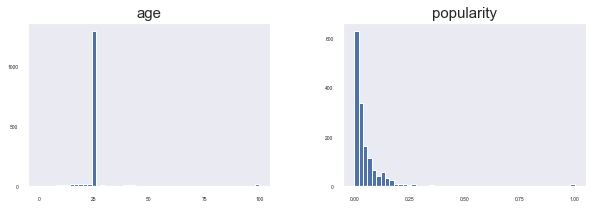

In [150]:
num_test_features.hist(figsize=(10, 3), bins=50,xlabelsize=5, ylabelsize=5, grid=False);

In [151]:
X_test_real = data[['age', 'popularity', 'numDeadRelations', 'male', 'isNoble', 'culture', 'house']]
y_test_pred = model.predict(X_test_real.values)

In [152]:
print(y_test_pred)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 1
 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 1 1 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 1 1 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]


In [153]:
isAlive_probabilities = model.predict_proba(X_test_real.values)
print("\nВероятности прогнозов (первые 5 записей):")
print(isAlive_probabilities[:5])


Вероятности прогнозов (первые 5 записей):
[[0.42587692 0.57412308]
 [0.18370353 0.81629647]
 [0.1313982  0.8686018 ]
 [0.29508693 0.70491307]
 [0.31497923 0.68502077]]


In [154]:
submission = pd.read_csv("submission.csv", index_col='S.No')

ValueError: Index S.No invalid

In [155]:
submission

,isAlive
S.No,
1558,1
1559,1
1560,1
1561,1
1562,1
...,...
1942,1
1943,1
1944,1


In [156]:
submission['isAlive'] = y_test_pred

In [157]:
submission.to_csv("submission.csv", index=False)